In [ ]:
import pandas as pd
import re
from collections import defaultdict
import pathlib
investment_path = pathlib.Path('exports') / 'investment_results.xlsx'

DA_PARAM_IDX = {
    'Q_D': ['j', 't'],
    'Q_RU_req': ['j', 't'],
    'Q_RD_req': ['j', 't'],
    'p_w_E': ['j', 'w', 't'],
    'q_w_E': ['j', 'w', 't'],
    'p_g_E_DA': ['j', 'g', 't'],
    'q_g_DA': ['j', 'g'],
    'p_g_RU_DA': ['j', 'g', 't'],
    'q_g_RU_max': ['j', 'g'],
    'p_g_RD_DA': ['j', 'g', 't'],
    'q_g_RD_max': ['j', 'g'],
}


RT_PARAM_IDX = {
    'p_g_E_RT': ['j', 'g', 't'],
    'q_g_RT': ['j', 'g'],
    'q_w_real': ['j', 'w', 't'],
}


DA_VAR_IDX = {
    'lambda_E_DA': ['j', 't'],
    'lambda_RU_DA': ['j', 't'],
    'lambda_RD_DA': ['j', 't'],
    'p_s_ch_DA': ['j', 's', 't'],
    'p_s_dch_DA': ['j', 's', 't'],
    'p_s_RU_DA': ['j', 's', 't'],
    'p_s_RD_DA': ['j', 's', 't'],
    'q_s_ch_DA': ['j', 's', 't'],
    'q_s_dch_DA': ['j', 's', 't'],
    'q_s_RU_DA': ['j', 's', 't'],
    'q_s_RD_DA': ['j', 's', 't'],
    'bar_q_s_ch_DA': ['j', 's', 't'],
    'bar_q_s_dch_DA': ['j', 's', 't'],
    'bar_q_s_RU_DA': ['j', 's', 't'],
    'bar_q_s_RD_DA': ['j', 's', 't'],
    'bar_q_w_E_DA': ['j', 'w', 't'],
    'bar_q_g_E_DA': ['j', 'g', 't'],
    'bar_q_g_RU_DA': ['j', 'g', 't'],
    'bar_q_g_RD_DA': ['j', 'g', 't'],
    'q_trans_1to2': ['j', 't'],
    'q_trans_2to1': ['j', 't'],
    'bar_q_trans_1to2': ['j', 't'],
    'bar_q_trans_2to1': ['j', 't'],
    'E_s_t': ['j', 's', 't'],
    'omega_s1': ['j', 't', 'state'],
    'omega_s2': ['j', 't', 'state'],
}
RT_VAR_IDX = {
    'lambda_RT': ['j', 't'],
    'p_s_ch_RT': ['j', 's', 't'],
    'p_s_dch_RT': ['j', 's', 't'],
    'q_s_ch_RT': ['j', 's', 't'],
    'q_s_dch_RT': ['j', 's', 't'],
    'bar_q_s_ch_RT': ['j', 's', 't'],
    'bar_q_s_dch_RT': ['j', 's', 't'],
    'bar_q_s_RU_RT': ['j', 's', 't'],
    'bar_q_s_RD_RT': ['j', 's', 't'],
    'bar_q_g_E_RT': ['j', 'g', 't'],
    'bar_q_g_RU_RT': ['j', 'g', 't'],
    'bar_q_g_RD_RT': ['j', 'g', 't'],
}

_ALL_IDX = {**DA_PARAM_IDX, **RT_PARAM_IDX, **DA_VAR_IDX, **RT_VAR_IDX}


def _normalize_scalar(val):
    if isinstance(val, float) and val.is_integer():
        return int(val)
    return val


def _df_to_mapping(df, idx_cols):
    data = {}
    for _, row in df.iterrows():
        key = tuple(_normalize_scalar(row[c]) for c in idx_cols)
        if len(key) == 1:
            key = key[0]
        data[key] = row['value']
    return data


def _parse_j_from_path(path):
    m = re.search(r'j(\d+)', path.stem)
    return int(m.group(1)) if m else None


def load_export_only(base_dir='exports', j=None):
    base = pathlib.Path(base_dir)
    if j is None:
        files = sorted(base.glob('market_export_j*.xlsx'))
    elif isinstance(j, (list, tuple, set)):
        files = [base / f'market_export_j{int(j_val)}.xlsx' for j_val in j]
    else:
        files = [base / f'market_export_j{int(j)}.xlsx']

    if not files:
        raise FileNotFoundError('未找到任何 market_export_j*.xlsx 文件')

    aggregated = {name: {} for name in _ALL_IDX}
    per_j = {}
    for path in files:
        if not path.exists():
            print(f'skip missing file: {path}')
            continue
        j_val = _parse_j_from_path(path)
        with pd.ExcelFile(path) as xls:
            da_params_df = pd.read_excel(xls, 'DA_params')
            rt_params_df = pd.read_excel(xls, 'RT_params')
            da_vars_df = pd.read_excel(xls, 'DA_vars')
            rt_vars_df = pd.read_excel(xls, 'RT_vars')

        merged = pd.concat([da_params_df, rt_params_df, da_vars_df, rt_vars_df], ignore_index=True)
        per_j[j_val] = {}
        for name, idx_cols in _ALL_IDX.items():
            sub = merged[merged['item'] == name]
            mapping = _df_to_mapping(sub, idx_cols)
            aggregated[name].update(mapping)
            per_j[j_val][name] = mapping

    for name, mapping in aggregated.items():
        globals()[name] = mapping
    return per_j


values_by_j_all = load_export_only(base_dir='exports')
investment_df = pd.read_excel(investment_path)
E_current = {row['storage']: row['investment_MWh'] for _, row in investment_df.iterrows()}

In [ ]:

def _storage_profit_by_day_no_trans():
    da_energy = {j: {s: 0.0 for s in S} for j in J}
    da_reserve = {j: {s: 0.0 for s in S} for j in J}
    rt_profit = {j: {s: 0.0 for s in S} for j in J}

    for j in J:
        for t in range(T):
            for s in S:
                da_energy[j][s] += (
                    lambda_E_DA[j, t] * (bar_q_s_dch_DA[j, s, t] - bar_q_s_ch_DA[j, s, t])
                    - params['c_s'][s] * (bar_q_s_dch_DA[j, s, t] + bar_q_s_ch_DA[j, s, t])
                )
                da_reserve[j][s] += (
                    lambda_RU_DA[j, t] * bar_q_s_RU_DA[j, s, t]
                    + lambda_RD_DA[j, t] * bar_q_s_RD_DA[j, s, t]
                )
                rt_profit[j][s] += (
                    (lambda_RT[j, t] - params['c_s'][s]) * (bar_q_s_RU_RT[j, s, t] + bar_q_s_dch_RT[j, s, t])
                    - (lambda_RT[j, t] + params['c_s'][s]) * (bar_q_s_RD_RT[j, s, t] + bar_q_s_ch_RT[j, s, t])
                )

    total_profit_j = {}
    for j in J:
        profit_j = sum(da_energy[j][s] + da_reserve[j][s] + rt_profit[j][s] for s in S)
        total_profit_j[j] = params['gamma'][j] * profit_j

    return da_energy, da_reserve, rt_profit, total_profit_j

da_energy_j, da_reserve_j, rt_profit_j, total_profit_j = _storage_profit_by_day_no_trans()


rows = []
for j in J:
    for s in S:
        da_total = da_energy_j[j][s] + da_reserve_j[j][s]
        total_unweighted = da_total + rt_profit_j[j][s]
        rows.append({
            'j': j,
            's': s,
            'DA_energy': da_energy_j[j][s],
            'DA_reserve': da_reserve_j[j][s],
            'DA_total': da_total,
            'RT_profit': rt_profit_j[j][s],
            'total_unweighted': total_unweighted,
            'total_weighted': params['gamma'][j] * total_unweighted,
        })

detail_df = pd.DataFrame(rows)
print(detail_df)


summary_rows = []
for j in J:
    summary_rows.append({
        'j': j,
        'DA_energy_total': sum(da_energy_j[j][s] for s in S),
        'DA_reserve_total': sum(da_reserve_j[j][s] for s in S),
        'DA_total': sum(da_energy_j[j][s] + da_reserve_j[j][s] for s in S),
        'RT_profit_total': sum(rt_profit_j[j][s] for s in S),
        'profit_j_unweighted': sum(da_energy_j[j][s] + da_reserve_j[j][s] + rt_profit_j[j][s] for s in S),
        'profit_j_weighted': total_profit_j[j],
        'gamma_j': params['gamma'][j],
    })

summary_df_no_trans = pd.DataFrame(summary_rows)
print(summary_df_no_trans)

total_investment = sum(params['C_inv'][s] * E_current[s] for s in S)
total_storage_profit = sum(total_profit_j[j] for j in J)

export_dir = pathlib.Path("exports")
export_dir.mkdir(parents=True, exist_ok=True)

detail_df.to_excel(export_dir / "summary_s.xlsx", index=False)
summary_df_no_trans.to_excel(export_dir / "summary_total.xlsx", index=False)

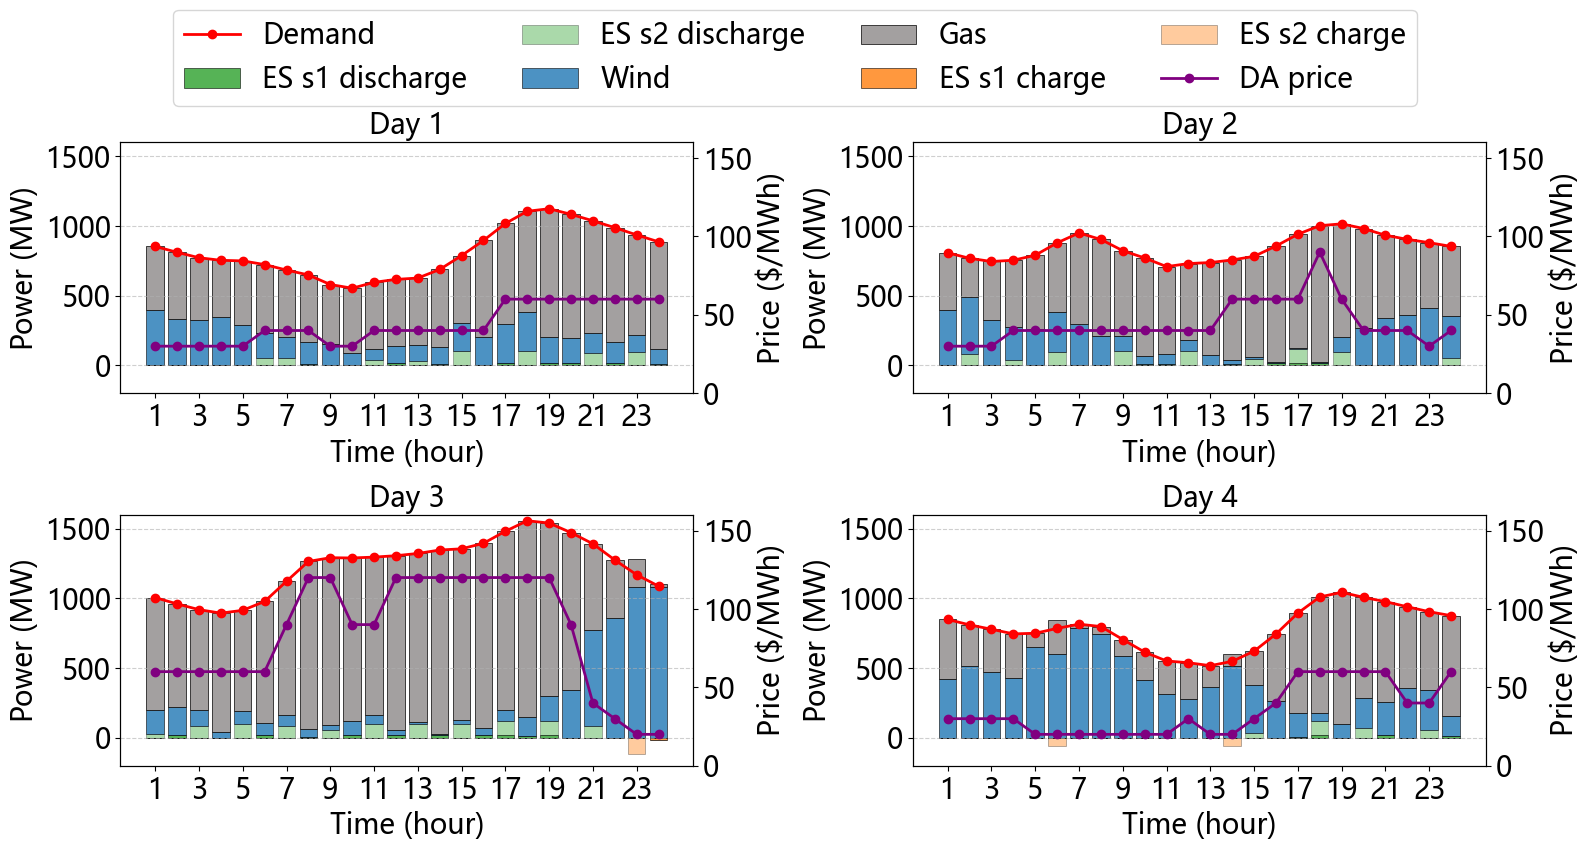

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager


def plot_DA_balance_subplots():
    available_fonts = {f.name for f in font_manager.fontManager.ttflist}
    preferred_fonts = ['Microsoft YaHei', 'SimHei']
    fallback_font = 'DejaVu Sans'
    for name in preferred_fonts:
        if name in available_fonts:
            plt.rcParams['font.family'] = name
            break
    else:
        plt.rcParams['font.family'] = fallback_font
    plt.rcParams['axes.unicode_minus'] = False
    plt.rcParams['xtick.labelsize'] = 20
    plt.rcParams['ytick.labelsize'] = 20
    fig, axes = plt.subplots(2, 2, figsize=(16, 8))
    axes = axes.flatten()
    
    for idx, j in enumerate(range(4)):
        ax1 = axes[idx]
        
        hours = list(range(T))
        hours_plot = list(range(1, T + 1))
        
        # Storage discharge/charge (DA)
        s1_dch = [bar_q_s_dch_DA[j, 's1', t] for t in hours]
        s2_dch = [bar_q_s_dch_DA[j, 's2', t] for t in hours]
        s1_ch = [bar_q_s_ch_DA[j, 's1', t] for t in hours]
        s2_ch = [bar_q_s_ch_DA[j, 's2', t] for t in hours]
        
        # Wind and gas
        wind_total = [sum(bar_q_w_E_DA[j, w, t] for w in W) for t in hours]
        gas_total = [sum(bar_q_g_E_DA[j, g, t] for g in G) for t in hours]
        demand = [Q_D[j, t] for t in hours]
        
        ele_price = [lambda_E_DA[j, t] for t in hours]
        p_ES_dch = [p_s_dch_DA[j, 's2', t] for t in hours]
        p_ES_ch = [p_s_ch_DA[j, 's2', t] for t in hours]
        
        s1_ch_neg = [-c for c in s1_ch]
        s2_ch_neg = [-c for c in s2_ch]
        
        # Colors
        color_dch = '#2ca02c'
        color_wind = '#1f77b4'
        color_gas = "#a3a0a0"
        color_ch = '#ff7f0e'
        
        # Supply stack
        bottom = np.zeros(len(hours))
        ax1.bar(hours_plot, s1_dch, bottom=bottom, label='ES s1 discharge', color=color_dch, edgecolor='black', linewidth=0.5, alpha=0.8)
        bottom += np.array(s1_dch)
        ax1.bar(hours_plot, s2_dch, bottom=bottom, label='ES s2 discharge', color=color_dch, edgecolor='black', linewidth=0.5, alpha=0.4)
        bottom += np.array(s2_dch)
        ax1.bar(hours_plot, wind_total, bottom=bottom, label='Wind', color=color_wind, edgecolor='black', linewidth=0.5, alpha=0.8)
        bottom += np.array(wind_total)
        ax1.bar(hours_plot, gas_total, bottom=bottom, label='Gas', color=color_gas, edgecolor='black', linewidth=0.5)
        
        # Charging (negative)
        bottom_ch = np.zeros(len(hours))
        ax1.bar(hours_plot, s1_ch_neg, bottom=bottom_ch, label='ES s1 charge', color=color_ch, edgecolor='black', linewidth=0.5, alpha=0.8)
        bottom_ch += np.array(s1_ch_neg)
        ax1.bar(hours_plot, s2_ch_neg, bottom=bottom_ch, label='ES s2 charge', color=color_ch, edgecolor='black', linewidth=0.5, alpha=0.4)
        
        # Balance check
        es_dch_total = [a + b for a, b in zip(s1_dch, s2_dch)]
        es_ch_total = [a + b for a, b in zip(s1_ch, s2_ch)]
        total_supply = np.array(es_dch_total) - np.array(es_ch_total) + np.array(wind_total) + np.array(gas_total)
        ax1.plot(hours_plot, demand, 'r-', marker='o', linewidth=2, label='Demand', zorder=10)
        # ax1.plot(hours_plot, total_supply - np.array(demand), 'k--', linewidth=1.5, label='Supply minus demand', zorder=11)
        
        ax1.set_xlabel('Time (hour)', fontsize=20)
        ax1.set_ylabel('Power (MW)', fontsize=20)
        ax1.set_title(f'Day {j+1}', fontsize=20)
        ax1.grid(axis='y', linestyle='--', alpha=0.6)
        ax1.set_xticks(hours_plot[::2])
        ax1.set_ylim(-200, 1600)
        # Price on secondary y-axis
        ax2 = ax1.twinx()
        ax2.plot(hours_plot, ele_price, 'purple',marker='o',  linewidth=2, label='DA price', zorder=12)
        # ax2.plot(hours_plot, p_ES_dch, color='darkviolet', ls='--', linewidth=2, label='ES s2 discharge offer', zorder=12)
        # ax2.plot(hours_plot, p_ES_ch, color='black', ls=':', linewidth=2, label='ES s2 charge bid', zorder=12)
        ax2.set_ylim(0, 160)
        ax2.set_ylabel('Price ($/MWh)', fontsize=20)
        
        # Only show legend for first subplot
        if idx == 0:
            handles1, labels1 = ax1.get_legend_handles_labels()
            handles2, labels2 = ax2.get_legend_handles_labels()
            fig.legend(handles1 + handles2, labels1 + labels2, loc='upper center', bbox_to_anchor=(0.5, 1.075), ncol=4, fontsize=20)
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    
    # Save figure to plots folder
    plots_dir = pathlib.Path("plots")
    plots_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(plots_dir / "Balance_DA_subplots_IEEE.png", dpi=300, bbox_inches='tight')

    plt.show()

plot_DA_balance_subplots()

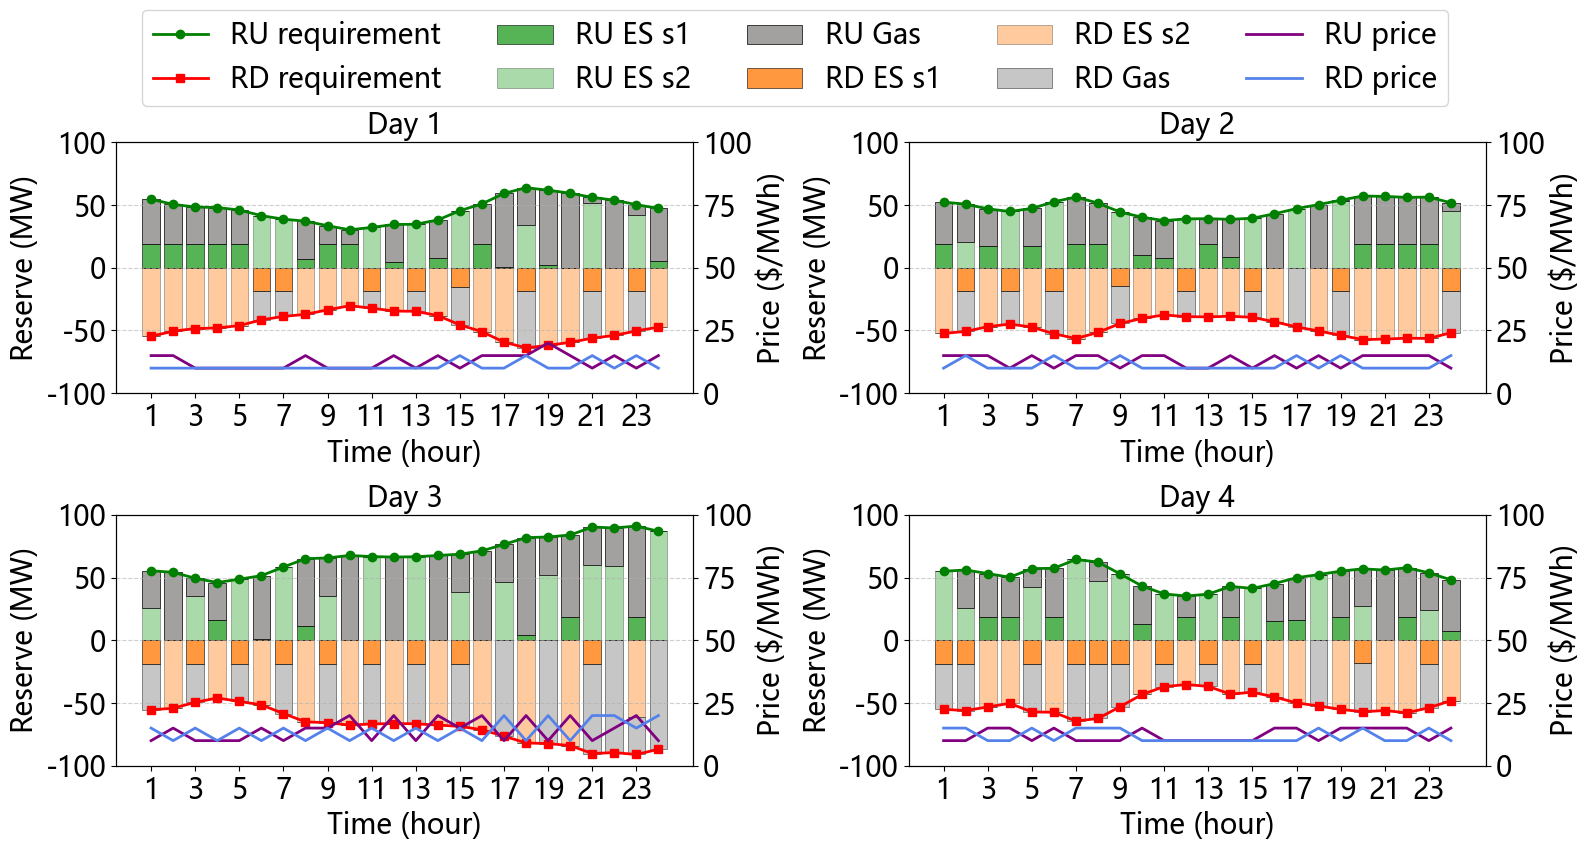

In [14]:
def plot_DA_reserve_subplots():
    available_fonts = {f.name for f in font_manager.fontManager.ttflist}
    preferred_fonts = ['Microsoft YaHei', 'SimHei']
    fallback_font = 'DejaVu Sans'
    for name in preferred_fonts:
        if name in available_fonts:
            plt.rcParams['font.family'] = name
            break
    else:
        plt.rcParams['font.family'] = fallback_font
    plt.rcParams['axes.unicode_minus'] = False
    plt.rcParams['xtick.labelsize'] = 20
    plt.rcParams['ytick.labelsize'] = 20
    fig, axes = plt.subplots(2, 2, figsize=(16, 8))
    axes = axes.flatten()

    for idx, j in enumerate(range(4)):
        ax1 = axes[idx]

        hours = list(range(T))
        hours_plot = list(range(1, T + 1))

        # RU/RD supply from storage and gas
        ru_s1 = [bar_q_s_RU_DA[j, 's1', t] for t in hours]
        ru_s2 = [bar_q_s_RU_DA[j, 's2', t] for t in hours]
        ru_gas = [sum(bar_q_g_RU_DA[j, g, t] for g in G) for t in hours]

        rd_s1 = [-bar_q_s_RD_DA[j, 's1', t] for t in hours]
        rd_s2 = [-bar_q_s_RD_DA[j, 's2', t] for t in hours]
        rd_gas = [-(sum(bar_q_g_RD_DA[j, g, t] for g in G)) for t in hours]

        ru_req = [Q_RU_req[j, t] for t in hours]
        rd_req = [Q_RD_req[j, t] for t in hours]

        # Colors
        color_ru = '#2ca02c'
        color_rd = '#ff7f0e'
        color_gas = "#a3a0a0"

        # RU stack
        bottom = np.zeros(len(hours))
        ax1.bar(hours_plot, ru_s1, bottom=bottom, label='RU ES s1', color=color_ru, edgecolor='black', linewidth=0.5, alpha=0.8)
        bottom += np.array(ru_s1)
        ax1.bar(hours_plot, ru_s2, bottom=bottom, label='RU ES s2', color=color_ru, edgecolor='black', linewidth=0.5, alpha=0.4)
        bottom += np.array(ru_s2)
        ax1.bar(hours_plot, ru_gas, bottom=bottom, label='RU Gas', color=color_gas, edgecolor='black', linewidth=0.5)

        # RD stack (negative)
        bottom_rd = np.zeros(len(hours))
        ax1.bar(hours_plot, rd_s1, bottom=bottom_rd, label='RD ES s1', color=color_rd, edgecolor='black', linewidth=0.5, alpha=0.8)
        bottom_rd += np.array(rd_s1)
        ax1.bar(hours_plot, rd_s2, bottom=bottom_rd, label='RD ES s2', color=color_rd, edgecolor='black', linewidth=0.5, alpha=0.4)
        bottom_rd += np.array(rd_s2)
        ax1.bar(hours_plot, rd_gas, bottom=bottom_rd, label='RD Gas', color=color_gas, edgecolor='black', linewidth=0.5, alpha=0.6)

        # Requirement lines
        ax1.plot(hours_plot, ru_req, 'g-', marker='o', linewidth=2, label='RU requirement', zorder=10)
        ax1.plot(hours_plot, -np.array(rd_req), 'r-', marker='s', linewidth=2, label='RD requirement', zorder=10)

        ax1.set_xlabel('Time (hour)', fontsize=20)
        ax1.set_ylabel('Reserve (MW)', fontsize=20)
        ax1.set_title(f'Day {j+1}', fontsize=20)
        ax1.grid(axis='y', linestyle='--', alpha=0.6)
        ax1.set_xticks(hours_plot[::2])
        ax1.set_ylim(-100, 100)
        # Price on secondary y-axis
        ax2 = ax1.twinx()
        ax2.plot(hours_plot, [lambda_RU_DA[j, t] for t in hours], 'purple',linewidth=2, label='RU price', zorder=12)
        ax2.plot(hours_plot, [lambda_RD_DA[j, t] for t in hours], color="#5582ea", linewidth=2, label='RD price', zorder=12)
        ax2.set_ylim(0, 100)
        ax2.set_ylabel('Price ($/MWh)', fontsize=20)

        if idx == 0:
            handles1, labels1 = ax1.get_legend_handles_labels()
            handles2, labels2 = ax2.get_legend_handles_labels()
            fig.legend(handles1 + handles2, labels1 + labels2, loc='upper center', bbox_to_anchor=(0.5, 1.075), ncol=5, fontsize=20)

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    plots_dir = pathlib.Path("plots")
    plots_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(plots_dir / "Balance_DA_reserve_subplots_IEEE.png", dpi=300, bbox_inches='tight')
    plt.show()

plot_DA_reserve_subplots()

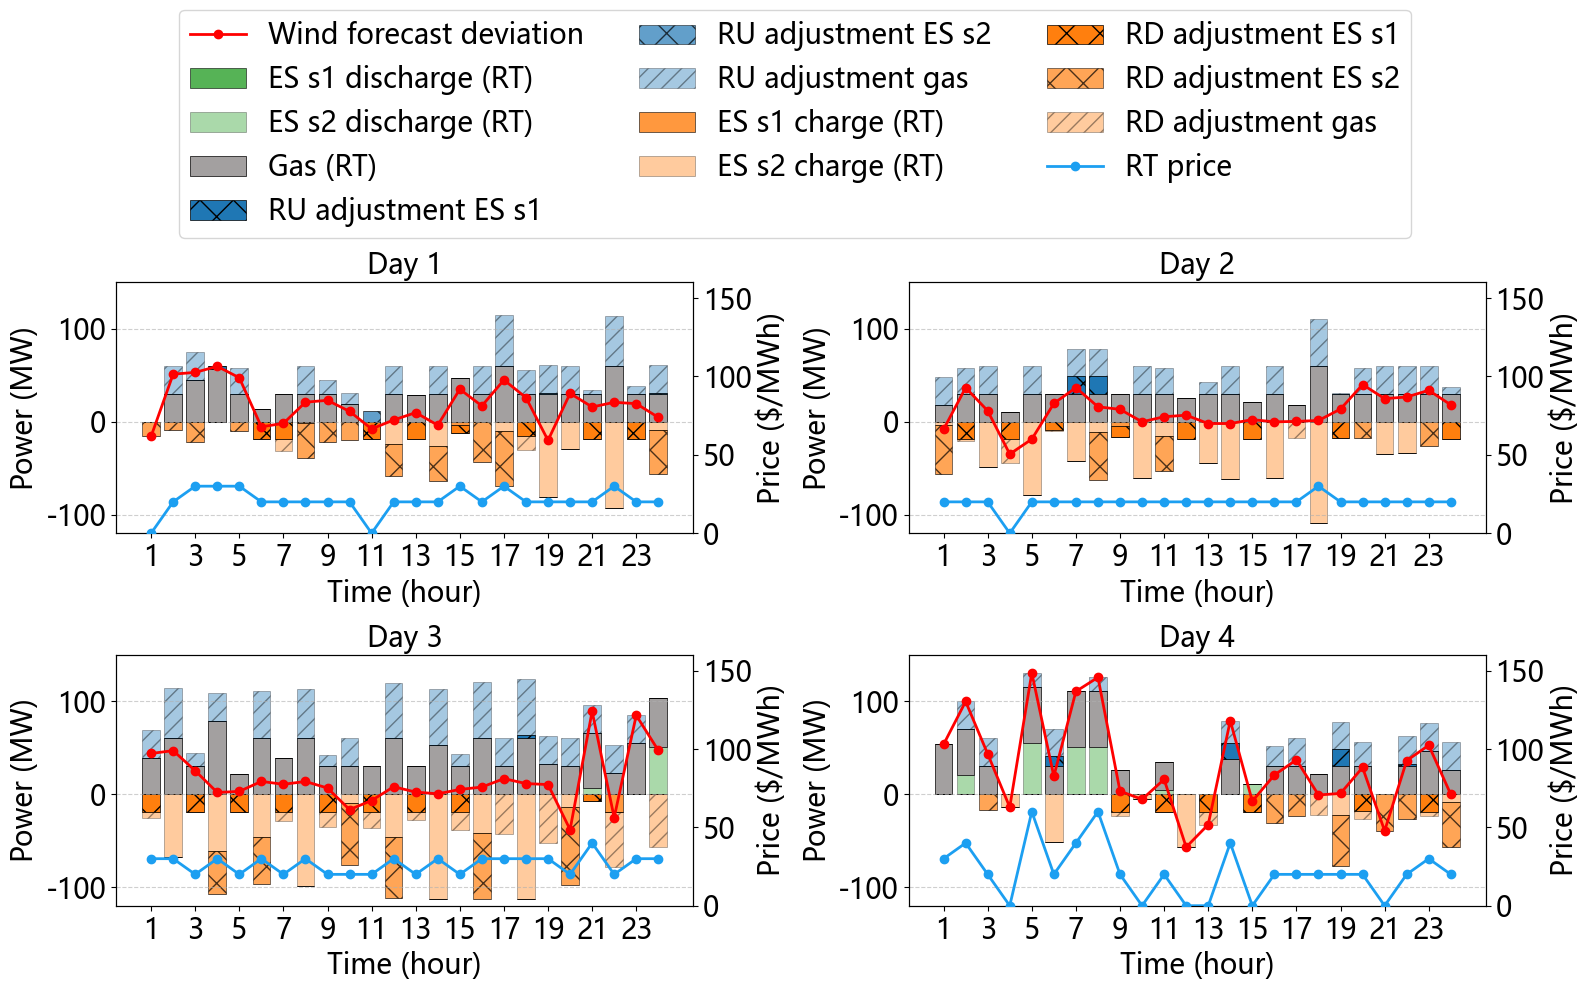

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager


def plot_RT_balance_subplots():
    available_fonts = {f.name for f in font_manager.fontManager.ttflist}
    preferred_fonts = ['Microsoft YaHei', 'SimHei']
    fallback_font = 'DejaVu Sans'
    for name in preferred_fonts:
        if name in available_fonts:
            plt.rcParams['font.family'] = name
            break
    else:
        plt.rcParams['font.family'] = fallback_font
    plt.rcParams['axes.unicode_minus'] = False
    plt.rcParams['xtick.labelsize'] = 20
    plt.rcParams['ytick.labelsize'] = 20
    def pick_dict(name, j=None, fallback=None):
        if name in globals():
            return globals()[name]
        if j is not None and 'values_by_j_all' in globals():
            return values_by_j_all.get(j, {}).get(name, fallback if fallback is not None else {})
        return fallback if fallback is not None else {}

    def get_val(d, *key):
        if not isinstance(d, dict):
            return 0.0
        tkey = tuple(key)
        if tkey in d:
            return d.get(tkey, 0.0)
        if len(key) > 1 and key[-1] in d:
            return d.get(key[-1], 0.0)
        if len(key) == 1 and key[0] in d:
            return d.get(key[0], 0.0)
        return 0.0

    fig, axes = plt.subplots(2, 2, figsize=(16, 8))
    axes = axes.flatten()

    for idx, j in enumerate(range(4)):
        ax1 = axes[idx]

        hours = list(range(T))
        hours_plot = list(range(1, T + 1))

        bar_q_s_dch = pick_dict('bar_q_s_dch_RT', j, q_s_dch_RT)
        bar_q_s_ch = pick_dict('bar_q_s_ch_RT', j, q_s_ch_RT)
        bar_q_g_E = pick_dict('bar_q_g_E_RT', j, pick_dict('q_g_RT', j, {}))
        bar_q_g_RU = pick_dict('bar_q_g_RU_RT', j, {})
        bar_q_g_RD = pick_dict('bar_q_g_RD_RT', j, {})
        bar_q_s_RU = pick_dict('bar_q_s_RU_RT', j, pick_dict('q_s_RU_DA', j, q_s_RU_DA))
        bar_q_s_RD = pick_dict('bar_q_s_RD_RT', j, pick_dict('q_s_RD_DA', j, q_s_RD_DA))
        bar_q_w_E = pick_dict('bar_q_w_E_DA', j, pick_dict('q_w_E', j, q_w_E))
        lambda_rt = pick_dict('lambda_RT', j, pick_dict('lambda_E_DA', j, {}))
        p_s_dch = pick_dict('p_s_dch_RT', j, {})
        p_s_ch = pick_dict('p_s_ch_RT', j, {})

        # Storage discharge/charge (RT)
        s1_dch = [get_val(bar_q_s_dch, j, 's1', t) for t in hours]
        s2_dch = [get_val(bar_q_s_dch, j, 's2', t) for t in hours]
        s1_ch = [get_val(bar_q_s_ch, j, 's1', t) for t in hours]
        s2_ch = [get_val(bar_q_s_ch, j, 's2', t) for t in hours]

        # Gas real-time energy
        gas_total = [sum(get_val(bar_q_g_E, j, g, t) for g in G) for t in hours]

        # RU/RD adjustments split
        ru_s1 = [get_val(bar_q_s_RU, j, 's1', t) for t in hours]
        ru_s2 = [get_val(bar_q_s_RU, j, 's2', t) for t in hours]
        ru_gas = [sum(get_val(bar_q_g_RU, j, g, t) for g in G) for t in hours]

        rd_s1 = [-get_val(bar_q_s_RD, j, 's1', t) for t in hours]
        rd_s2 = [-get_val(bar_q_s_RD, j, 's2', t) for t in hours]
        rd_gas = [-(sum(get_val(bar_q_g_RD, j, g, t) for g in G)) for t in hours]

        # Wind forecast deviation
        wind_dev = [sum(get_val(bar_q_w_E, j, w, t) - get_val(q_w_real, j, w, t) for w in W) for t in hours]

        ele_price = [get_val(lambda_rt, j, t) for t in hours]
        p_ES_dch = [get_val(p_s_dch, j, 's2', t) for t in hours]
        p_ES_ch = [get_val(p_s_ch, j, 's2', t) for t in hours]

        s1_ch_neg = [-c for c in s1_ch]
        s2_ch_neg = [-c for c in s2_ch]

        # Colors
        color_dch = '#2ca02c'
        color_ch = '#ff7f0e'
        color_gas = "#a3a0a0"
        color_ru = '#1f77b4'
        color_rd = '#ff7f0e'


        # Energy and RU stack
        bottom = np.zeros(len(hours))
        ax1.bar(hours_plot, s1_dch, bottom=bottom, label='ES s1 discharge (RT)', color=color_dch, edgecolor='black', linewidth=0.5, alpha=0.8)
        bottom += np.array(s1_dch)
        ax1.bar(hours_plot, s2_dch, bottom=bottom, label='ES s2 discharge (RT)', color=color_dch, edgecolor='black', linewidth=0.5, alpha=0.4)
        bottom += np.array(s2_dch)
        ax1.bar(hours_plot, gas_total, bottom=bottom, label='Gas (RT)', color=color_gas, edgecolor='black', linewidth=0.5)
        bottom += np.array(gas_total)

        ax1.bar(hours_plot, ru_s1, bottom=bottom, label='RU adjustment ES s1', color=color_ru, edgecolor='black', linewidth=0.5, hatch='x', alpha=1)
        bottom += np.array(ru_s1)
        ax1.bar(hours_plot, ru_s2, bottom=bottom, label='RU adjustment ES s2', color=color_ru, edgecolor='black', linewidth=0.5, hatch='x', alpha=0.7)
        bottom += np.array(ru_s2)
        ax1.bar(hours_plot, ru_gas, bottom=bottom, label='RU adjustment gas', color=color_ru, edgecolor='black', linewidth=0.5, hatch='//', alpha=0.4)

        # Charging and RD stack
        bottom_ch = np.zeros(len(hours))
        ax1.bar(hours_plot, s1_ch_neg, bottom=bottom_ch, label='ES s1 charge (RT)', color=color_ch, edgecolor='black', linewidth=0.5, alpha=0.8)
        bottom_ch += np.array(s1_ch_neg)
        ax1.bar(hours_plot, s2_ch_neg, bottom=bottom_ch, label='ES s2 charge (RT)', color=color_ch, edgecolor='black', linewidth=0.5, alpha=0.4)
        bottom_ch += np.array(s2_ch_neg)

        ax1.bar(hours_plot, rd_s1, bottom=bottom_ch, label='RD adjustment ES s1', color=color_rd, edgecolor='black', linewidth=0.5, hatch='x', alpha=1)
        bottom_ch += np.array(rd_s1)
        ax1.bar(hours_plot, rd_s2, bottom=bottom_ch, label='RD adjustment ES s2', color=color_rd, edgecolor='black', linewidth=0.5, hatch='x', alpha=0.7)
        bottom_ch += np.array(rd_s2)
        ax1.bar(hours_plot, rd_gas, bottom=bottom_ch, label='RD adjustment gas', color=color_rd, edgecolor='black', linewidth=0.5, hatch='//', alpha=0.4)

        # Balance check
        es_dch_total = [a + b for a, b in zip(s1_dch, s2_dch)]
        es_ch_total = [a + b for a, b in zip(s1_ch, s2_ch)]
        ru_total = np.array(ru_s1) + np.array(ru_s2) + np.array(ru_gas)
        rd_total = np.array(rd_s1) + np.array(rd_s2) + np.array(rd_gas)
        total_adjust = np.array(es_dch_total) - np.array(es_ch_total) + np.array(gas_total) + ru_total + rd_total

        ax1.plot(hours_plot, wind_dev, 'r-', marker='o', linewidth=2, label='Wind forecast deviation', zorder=10)
        # ax1.plot(hours_plot, total_adjust - np.array(wind_dev), 'k--', linewidth=1.5, label='Adjustment minus deviation', zorder=11)

        ax1.set_xlabel('Time (hour)', fontsize=20)
        ax1.set_ylabel('Power (MW)', fontsize=20)
        ax1.set_title(f'Day {j+1}', fontsize=20)
        ax1.grid(axis='y', linestyle='--', alpha=0.6)
        ax1.set_xticks(hours_plot[::2])
        ax1.set_ylim(-120, 150)
        # Price on secondary y-axis
        ax2 = ax1.twinx()
        ax2.plot(hours_plot, ele_price, color="#1c9ff1", marker='o', linewidth=2, label='RT price', zorder=12)
        # ax2.plot(hours_plot, p_ES_dch, color='darkviolet', ls='--', linewidth=2, label='ES s2 discharge offer (RT)', zorder=12)
        # ax2.plot(hours_plot, p_ES_ch, color='black', ls=':', linewidth=2, label='ES s2 charge bid (RT)', zorder=12)
        ax2.set_ylim(0, 160)
        ax2.set_ylabel('Price ($/MWh)', fontsize=20)

        if idx == 0:
            handles1, labels1 = ax1.get_legend_handles_labels()
            handles2, labels2 = ax2.get_legend_handles_labels()
            fig.legend(handles1 + handles2, labels1 + labels2, loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=3, fontsize=20)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
        # Save figure to plots folder
    plots_dir = pathlib.Path("plots")
    plots_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(plots_dir / "Balance_RT_subplots_IEEE.png", dpi=300, bbox_inches='tight')
    plt.show()


plot_RT_balance_subplots()

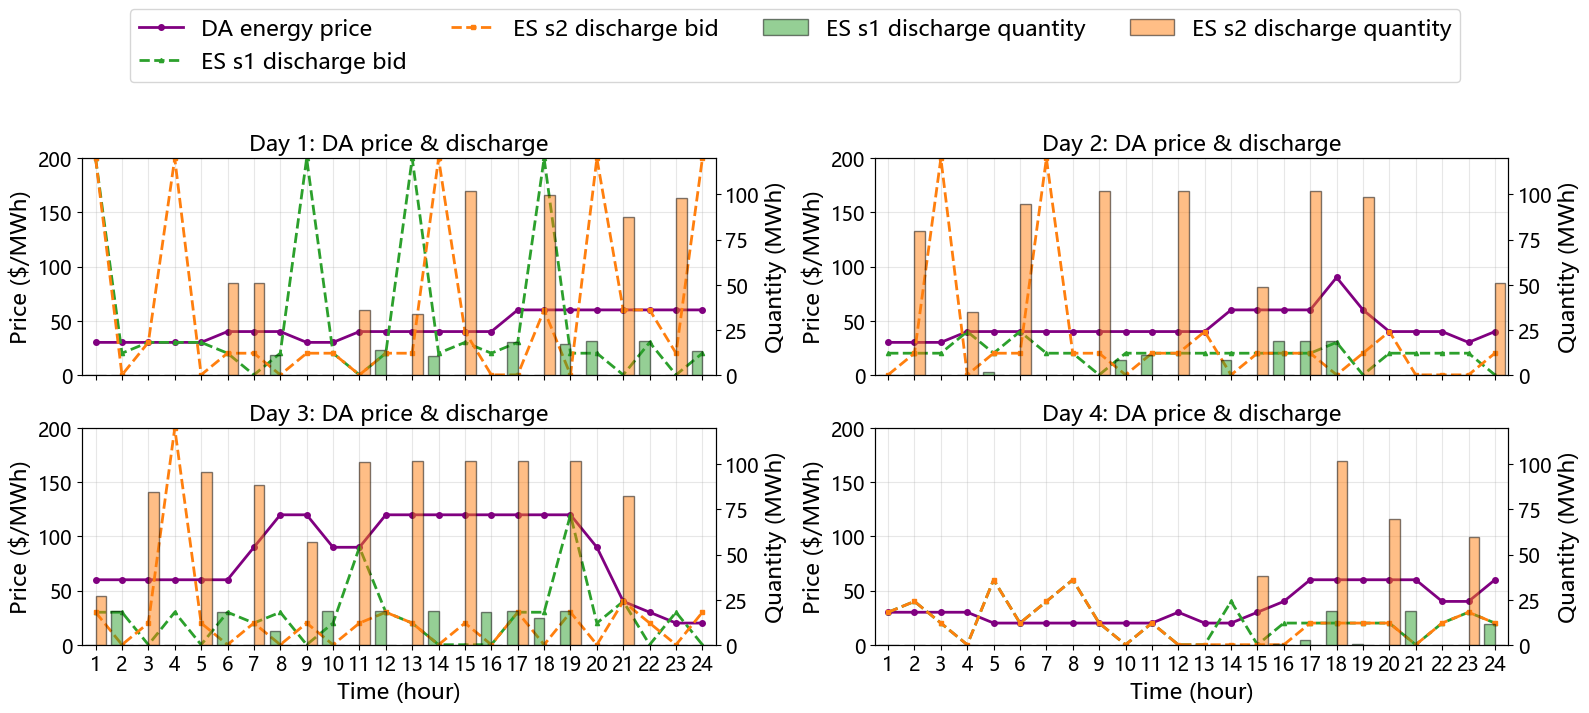

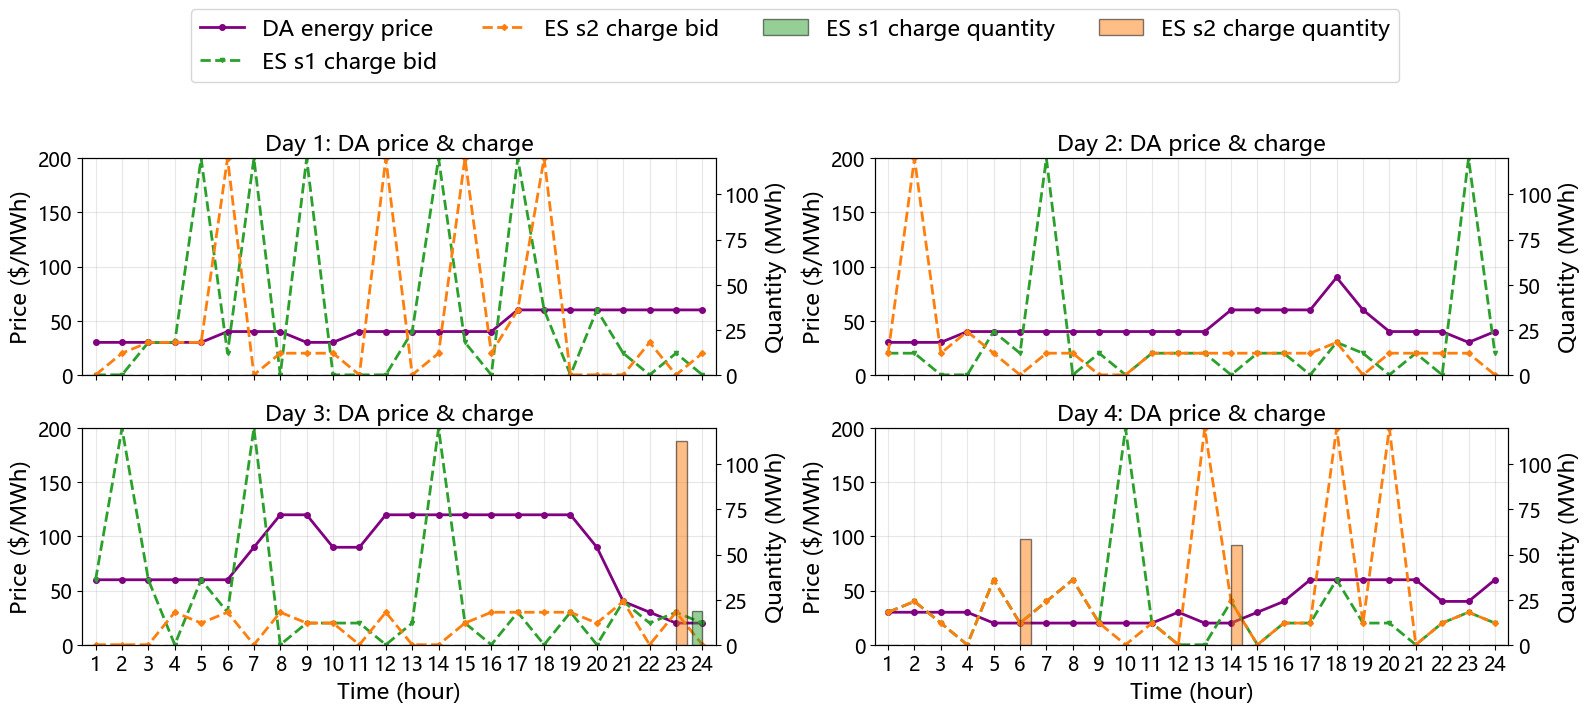

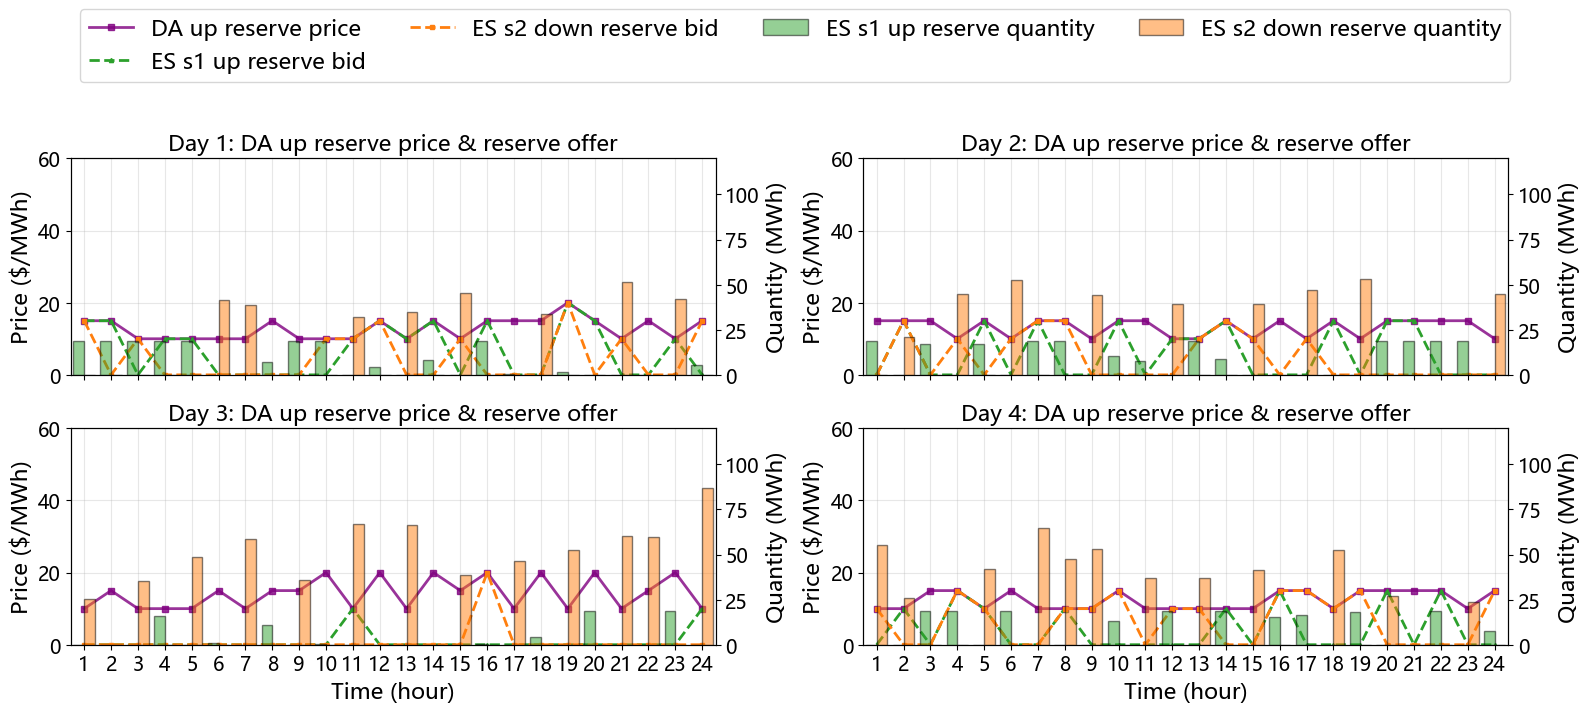

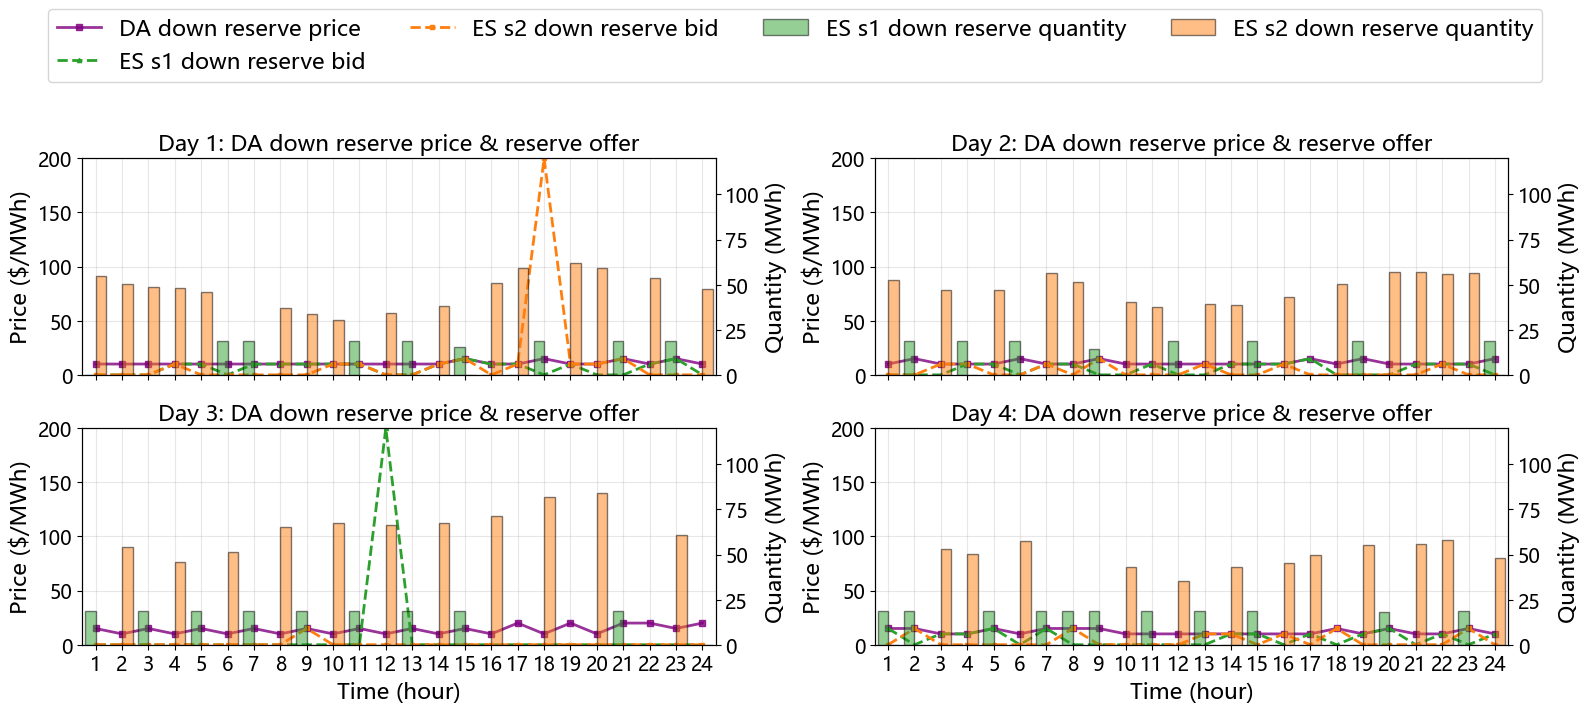

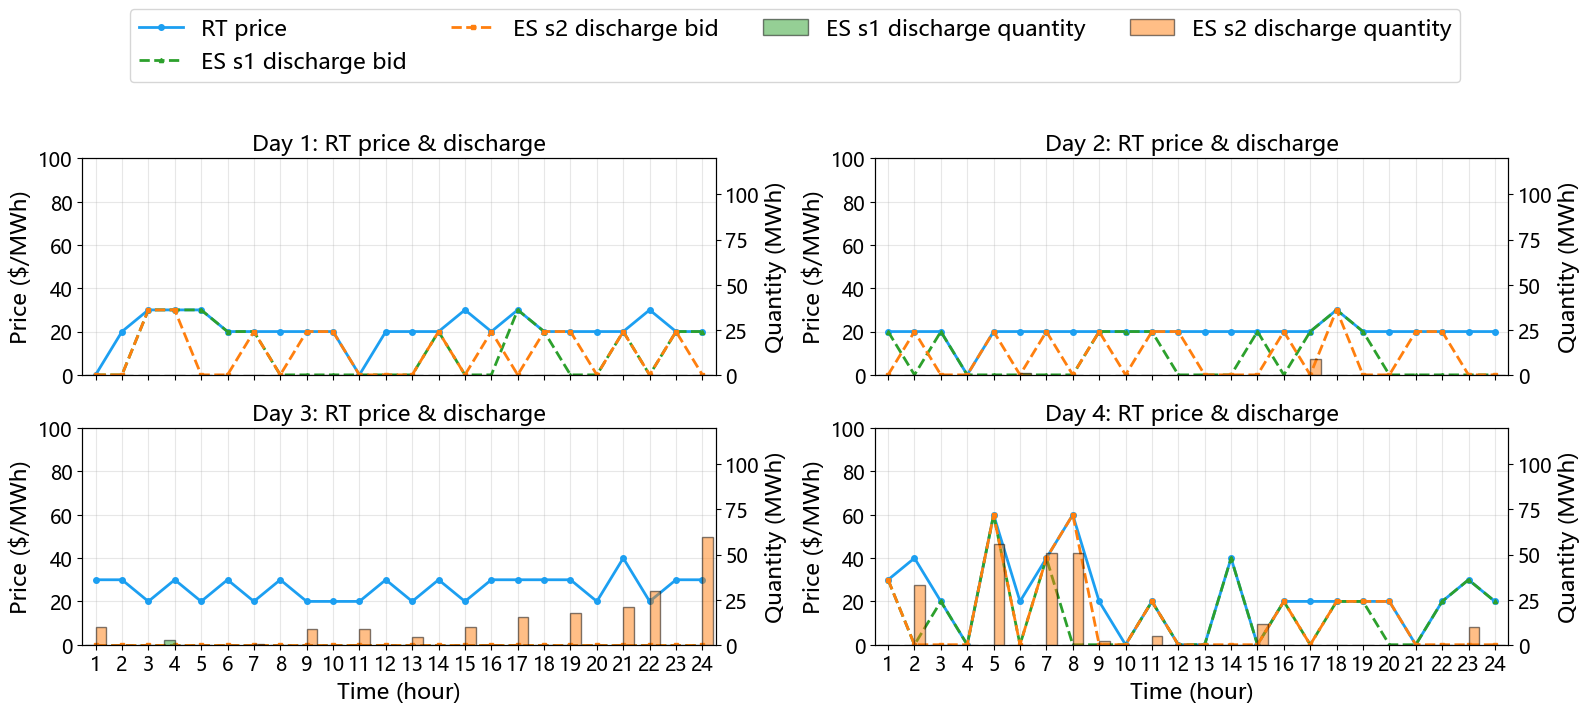

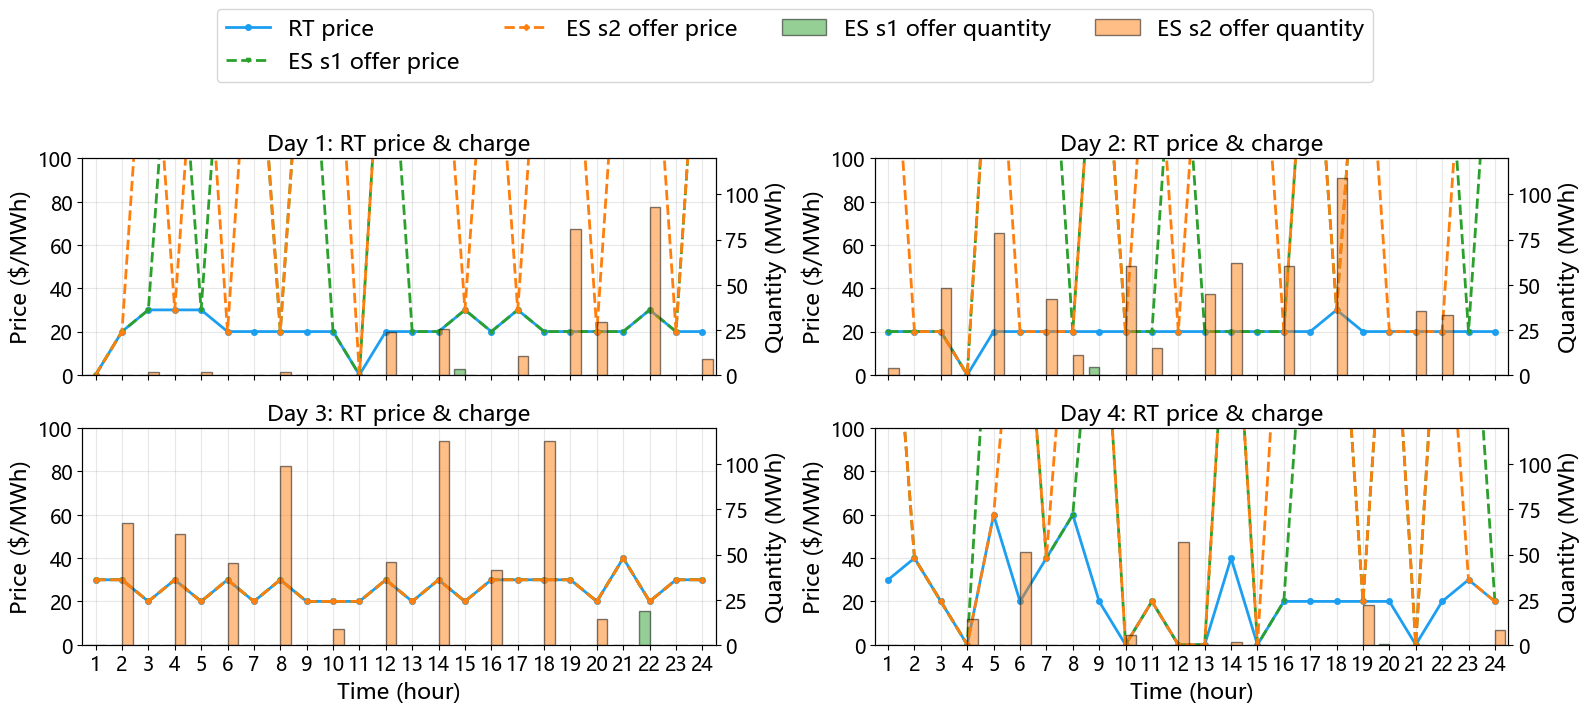

In [16]:
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
def plot_DA_prices_discharge():
    """Plot DA clearing price with ES discharge bids and discharge quantities"""
    hours = list(range(T))
    hours_plot = list(range(1, T + 1))
    n = len(J)
    nrows = math.ceil(n / 2)
    fig, axes = plt.subplots(nrows, 2, figsize=(16, 3 * nrows), sharex=True)
    axes = np.array(axes).reshape(nrows, 2)

    for idx, j in enumerate(J):
        r, c = divmod(idx, 2)
        ax = axes[r, c]
        ax2 = ax.twinx()
        
        # Get data from values_by_j_all
        da_price = [lambda_E_DA[j, t] for t in hours]
        s1_bid = [p_s_dch_DA[j, 's1', t] for t in hours]
        s2_bid = [p_s_dch_DA[j, 's2', t] for t in hours]

        s1_qty = [q_s_dch_DA[j, 's1', t] for t in hours]
        s2_qty = [q_s_dch_DA[j, 's2', t] for t in hours]
        
        # Plot prices on primary axis
        ax.plot(hours_plot, da_price, label='DA energy price', color='purple', linewidth=2, marker='o', markersize=4)
        ax.plot(hours_plot, s1_bid, label='ES s1 discharge bid', color='#2ca02c', linestyle='--', linewidth=2, marker='^', markersize=3)
        ax.plot(hours_plot, s2_bid, label='ES s2 discharge bid', color='#ff7f0e', linestyle='--', linewidth=2, marker='s', markersize=3)
        
        # Plot quantities on secondary axis
        ax2.bar([h - 0.2 for h in hours_plot], s1_qty, width=0.4, label='ES s1 discharge quantity', color='#2ca02c', edgecolor='black',  alpha=0.5)
        ax2.bar([h + 0.2 for h in hours_plot], s2_qty, width=0.4, label='ES s2 discharge quantity', color='#ff7f0e',  edgecolor='black', alpha=0.5)
        
        ax.set_xlim(0.5, T + 0.5)
        ax.set_xticks(hours_plot)
        ax.set_ylabel('Price ($/MWh)',fontsize=16)
        ax2.set_ylabel('Quantity (MWh)',fontsize=16)
        ax.set_title(f'Day {j+1}: DA price & discharge',fontsize=16)
        ax.grid(alpha=0.3)
        ax.set_ylim(0, 200)
        ax2.set_ylim(0, 120)
        if idx == 0:
            lines1, labels1 = ax.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            fig.legend(lines1 + lines2,labels1 + labels2,loc='upper center',bbox_to_anchor=(0.5, 1.2),ncol=4,fontsize=16)
    
    for idx in range(n, nrows * 2):
        r, c = divmod(idx, 2)
        axes[r, c].axis('off')
    
    axes[-1, 0].set_xlabel('Time (hour)',fontsize=16)
    axes[-1, 1].set_xlabel('Time (hour)',fontsize=16)
    plt.tight_layout()
    # Save figure to plots folder
    plots_dir = pathlib.Path("plots")
    plots_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(plots_dir / "ES_operation_DA_discharge.png", dpi=300, bbox_inches='tight')
    plt.show()

def plot_DA_prices_charge():
    """Plot DA clearing price with ES charge bids and charge quantities"""
    hours = list(range(T))
    hours_plot = list(range(1, T + 1))
    n = len(J)
    nrows = math.ceil(n / 2)
    fig, axes = plt.subplots(nrows, 2, figsize=(16, 3 * nrows), sharex=True)
    axes = np.array(axes).reshape(nrows, 2)
    
    for idx, j in enumerate(J):
        r, c = divmod(idx, 2)
        ax = axes[r, c]
        ax2 = ax.twinx()
        
        # Get data from values_by_j_all
        da_price = [lambda_E_DA[j, t] for t in hours]
        s1_bid = [p_s_ch_DA[j, 's1', t] for t in hours]
        s2_bid = [p_s_ch_DA[j, 's2', t] for t in hours]
        s1_qty = [q_s_ch_DA[j, 's1', t] for t in hours]
        s2_qty = [q_s_ch_DA[j, 's2', t] for t in hours]
        
        # Plot prices on primary axis
        ax.plot(hours_plot, da_price, label='DA energy price', color='purple', linewidth=2, marker='o', markersize=4)
        ax.plot(hours_plot, s1_bid, label='ES s1 charge bid', color='#2ca02c', linestyle='--', linewidth=2, marker='v', markersize=3)
        ax.plot(hours_plot, s2_bid, label='ES s2 charge bid', color='#ff7f0e', linestyle='--', linewidth=2, marker='D', markersize=3)
        
        # Plot quantities on secondary axis
        ax2.bar([h - 0.2 for h in hours_plot], s1_qty, width=0.4, label='ES s1 charge quantity', color='#2ca02c', edgecolor='black', alpha=0.5)
        ax2.bar([h + 0.2 for h in hours_plot], s2_qty, width=0.4, label='ES s2 charge quantity', color='#ff7f0e', edgecolor='black', alpha=0.5)
        
        ax.set_xlim(0.5, T + 0.5)
        ax.set_xticks(hours_plot)
        ax.set_ylabel('Price ($/MWh)',fontsize=16)
        ax2.set_ylabel('Quantity (MWh)',fontsize=16)
        ax.set_title(f'Day {j+1}: DA price & charge',fontsize=16)
        ax.grid(alpha=0.3)
        ax.set_ylim(0, 200)
        ax2.set_ylim(0, 120)
        
        if idx == 0:
            lines1, labels1 = ax.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            fig.legend(lines1 + lines2,labels1 + labels2,loc='upper center',bbox_to_anchor=(0.5, 1.2),ncol=4,fontsize=16)
    
    for idx in range(n, nrows * 2):
        r, c = divmod(idx, 2)
        axes[r, c].axis('off')
    
    axes[-1, 0].set_xlabel('Time (hour)',fontsize=16)
    axes[-1, 1].set_xlabel('Time (hour)',fontsize=16)
    plt.tight_layout()
    # Save figure to plots folder
    plots_dir = pathlib.Path("plots")
    plots_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(plots_dir / "ES_operation_DA_charge.png", dpi=300, bbox_inches='tight')
    plt.show()

def plot_DA_RU_prices_offer():
    """Plot DA reserve clearing price with ES up and down offer quantities"""
    hours = list(range(T))
    hours_plot = list(range(1, T + 1))
    n = len(J)
    nrows = math.ceil(n / 2)
    fig, axes = plt.subplots(nrows, 2, figsize=(16, 3 * nrows), sharex=True)
    axes = np.array(axes).reshape(nrows, 2)
    
    for idx, j in enumerate(J):
        r, c = divmod(idx, 2)
        ax = axes[r, c]
        ax2 = ax.twinx()
        
        # Get data from values_by_j_all
        da_price = [lambda_RU_DA[j, t] for t in hours]
        s1_bid = [p_s_RU_DA[j, 's1', t] for t in hours]
        s2_bid = [p_s_RU_DA[j, 's2', t] for t in hours]

        s1_qty = [q_s_RU_DA[j, 's1', t] for t in hours]
        s2_qty = [q_s_RU_DA[j, 's2', t] for t in hours]
        
        # Plot prices on primary axis
        ax.plot(hours_plot, da_price, label='DA up reserve price', color='purple', linewidth=2, marker='s', markersize=4,alpha=0.8)
        ax.plot(hours_plot, s1_bid, label='ES s1 up reserve bid', color='#2ca02c', linestyle='--', linewidth=2, marker='^', markersize=3)
        ax.plot(hours_plot, s2_bid, label='ES s2 down reserve bid', color='#ff7f0e', linestyle='--', linewidth=2, marker='s', markersize=3)
        
        # Plot quantities on secondary axis
        ax2.bar([h - 0.2 for h in hours_plot], s1_qty, width=0.4, label='ES s1 up reserve quantity', color='#2ca02c', edgecolor='black',  alpha=0.5)
        ax2.bar([h + 0.2 for h in hours_plot], s2_qty, width=0.4, label='ES s2 down reserve quantity', color='#ff7f0e',  edgecolor='black', alpha=0.5)
        
        ax.set_xlim(0.5, T + 0.5)
        ax.set_xticks(hours_plot)
        ax.set_ylabel('Price ($/MWh)',fontsize=16)
        ax2.set_ylabel('Quantity (MWh)',fontsize=16)
        ax.set_title(f'Day {j+1}: DA up reserve price & reserve offer',fontsize=16)
        ax.grid(alpha=0.3)
        ax.set_ylim(0, 60)
        ax2.set_ylim(0, 120)
        if idx == 0:
            lines1, labels1 = ax.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            fig.legend(lines1 + lines2,labels1 + labels2,loc='upper center',bbox_to_anchor=(0.5, 1.2),ncol=4,fontsize=16)
    
    for idx in range(n, nrows * 2):
        r, c = divmod(idx, 2)
        axes[r, c].axis('off')
    
    axes[-1, 0].set_xlabel('Time (hour)',fontsize=16)
    axes[-1, 1].set_xlabel('Time (hour)',fontsize=16)
    plt.tight_layout()
    # Save figure to plots folder
    plots_dir = pathlib.Path("plots")
    plots_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(plots_dir / "ES_operation_DA_RU_offer.png", dpi=300, bbox_inches='tight')
    plt.show()

def plot_DA_RD_prices_offer():
    """Plot DA reserve clearing price with ES up and down offer quantities"""
    hours = list(range(T))
    hours_plot = list(range(1, T + 1))
    n = len(J)
    nrows = math.ceil(n / 2)
    fig, axes = plt.subplots(nrows, 2, figsize=(16, 3 * nrows), sharex=True)
    axes = np.array(axes).reshape(nrows, 2)
    
    for idx, j in enumerate(J):
        r, c = divmod(idx, 2)
        ax = axes[r, c]
        ax2 = ax.twinx()
        
        # Get data from values_by_j_all
        da_price = [lambda_RD_DA[j, t] for t in hours]
        s1_bid = [p_s_RD_DA[j, 's1', t] for t in hours]
        s2_bid = [p_s_RD_DA[j, 's2', t] for t in hours]

        s1_qty = [q_s_RD_DA[j, 's1', t] for t in hours]
        s2_qty = [q_s_RD_DA[j, 's2', t] for t in hours]
        
        # Plot prices on primary axis
        ax.plot(hours_plot, da_price, label='DA down reserve price', color='purple', linewidth=2, marker='s', markersize=4,alpha=0.8)
        ax.plot(hours_plot, s1_bid, label='ES s1 down reserve bid', color='#2ca02c', linestyle='--', linewidth=2, marker='^', markersize=3)
        ax.plot(hours_plot, s2_bid, label='ES s2 down reserve bid', color='#ff7f0e', linestyle='--', linewidth=2, marker='s', markersize=3)
        
        # Plot quantities on secondary axis
        ax2.bar([h - 0.2 for h in hours_plot], s1_qty, width=0.4, label='ES s1 down reserve quantity', color='#2ca02c', edgecolor='black',  alpha=0.5)
        ax2.bar([h + 0.2 for h in hours_plot], s2_qty, width=0.4, label='ES s2 down reserve quantity', color='#ff7f0e',  edgecolor='black', alpha=0.5)
        
        ax.set_xlim(0.5, T + 0.5)
        ax.set_xticks(hours_plot)
        ax.set_ylabel('Price ($/MWh)',fontsize=16)
        ax2.set_ylabel('Quantity (MWh)',fontsize=16)
        ax.set_title(f'Day {j+1}: DA down reserve price & reserve offer',fontsize=16)
        ax.grid(alpha=0.3)
        ax.set_ylim(0, 200)
        ax2.set_ylim(0, 120)
        if idx == 0:
            lines1, labels1 = ax.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            fig.legend(lines1 + lines2,labels1 + labels2,loc='upper center',bbox_to_anchor=(0.5, 1.2),ncol=4,fontsize=16)
    
    for idx in range(n, nrows * 2):
        r, c = divmod(idx, 2)
        axes[r, c].axis('off')
    
    axes[-1, 0].set_xlabel('Time (hour)',fontsize=16)
    axes[-1, 1].set_xlabel('Time (hour)',fontsize=16)
    plt.tight_layout()
    # Save figure to plots folder
    plots_dir = pathlib.Path("plots")
    plots_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(plots_dir / "ES_operation_DA_RD_offer.png", dpi=300, bbox_inches='tight')
    plt.show()

def plot_RT_prices_discharge():
    """Plot RT clearing price with ES discharge bids and discharge quantities"""
    hours = list(range(T))
    hours_plot = list(range(1, T + 1))
    n = len(J)
    nrows = math.ceil(n / 2)
    fig, axes = plt.subplots(nrows, 2, figsize=(16, 3 * nrows), sharex=True)
    axes = np.array(axes).reshape(nrows, 2)
    
    for idx, j in enumerate(J):
        r, c = divmod(idx, 2)
        ax = axes[r, c]
        ax2 = ax.twinx()
        
        # Get data from values_by_j_all
        rt_price = [lambda_RT[j, t] for t in hours]
        s1_bid = [p_s_dch_RT[j, 's1', t] for t in hours]
        s2_bid = [p_s_dch_RT[j, 's2', t] for t in hours]
        s1_qty = [q_s_dch_RT[j, 's1', t] for t in hours]
        s2_qty = [q_s_dch_RT[j, 's2', t] for t in hours]
        
        # Plot prices on primary axis
        ax.plot(hours_plot, rt_price, label='RT price', color="#1c9ff1", linewidth=2, marker='o', markersize=4)
        ax.plot(hours_plot, s1_bid, label='ES s1 discharge bid', color='#2ca02c', linestyle='--', linewidth=2, marker='^', markersize=3)
        ax.plot(hours_plot, s2_bid, label='ES s2 discharge bid', color='#ff7f0e', linestyle='--', linewidth=2, marker='s', markersize=3)
        
        # Plot quantities on secondary axis
        ax2.bar([h - 0.2 for h in hours_plot], s1_qty, width=0.4, label='ES s1 discharge quantity', color='#2ca02c',  edgecolor='black', alpha=0.5)
        ax2.bar([h + 0.2 for h in hours_plot], s2_qty, width=0.4, label='ES s2 discharge quantity', color='#ff7f0e',  edgecolor='black', alpha=0.5)
        
        ax.set_xlim(0.5, T + 0.5)
        ax.set_xticks(hours_plot)
        ax.set_ylabel('Price ($/MWh)',fontsize=16)
        ax2.set_ylabel('Quantity (MWh)',fontsize=16)
        ax.set_title(f'Day {j+1}: RT price & discharge',fontsize=16)
        ax.grid(alpha=0.3)
        ax.set_ylim(0, 100)
        ax2.set_ylim(0, 120)
        if idx == 0:
            lines1, labels1 = ax.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            fig.legend(lines1 + lines2,labels1 + labels2,loc='upper center',bbox_to_anchor=(0.5, 1.2),ncol=4,fontsize=16)
    
    for idx in range(n, nrows * 2):
        r, c = divmod(idx, 2)
        axes[r, c].axis('off')
    
    axes[-1, 0].set_xlabel('Time (hour)',fontsize=16)
    axes[-1, 1].set_xlabel('Time (hour)',fontsize=16)
    plt.tight_layout()
    # Save figure to plots folder
    plots_dir = pathlib.Path("plots")
    plots_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(plots_dir / "ES_operation_RT_discharge.png", dpi=300, bbox_inches='tight')
    plt.show()

def plot_RT_prices_charge():
    """Plot RT clearing price with ES charge bids and charge quantities"""
    hours = list(range(T))
    hours_plot = list(range(1, T + 1))
    n = len(J)
    nrows = math.ceil(n / 2)
    fig, axes = plt.subplots(nrows, 2, figsize=(16, 3 * nrows), sharex=True)
    axes = np.array(axes).reshape(nrows, 2)
    
    for idx, j in enumerate(J):
        r, c = divmod(idx, 2)
        ax = axes[r, c]
        ax2 = ax.twinx()
        
        # Get data from values_by_j_all
        rt_price = [lambda_RT[j, t] for t in hours]
        s1_bid = [p_s_ch_RT[j, 's1', t] for t in hours]
        s2_bid = [p_s_ch_RT[j, 's2', t] for t in hours]
        s1_qty = [q_s_ch_RT[j, 's1', t] for t in hours]
        s2_qty = [q_s_ch_RT[j, 's2', t] for t in hours]
        
        # Plot prices on primary axis
        ax.plot(hours_plot, rt_price, label='RT price', color="#1c9ff1", linewidth=2, marker='o', markersize=4)
        ax.plot(hours_plot, s1_bid, label='ES s1 offer price', color='#2ca02c', linestyle='--', linewidth=2, marker='v', markersize=3)
        ax.plot(hours_plot, s2_bid, label='ES s2 offer price', color='#ff7f0e', linestyle='--', linewidth=2, marker='D', markersize=3)
        
        # Plot quantities on secondary axis
        ax2.bar([h - 0.2 for h in hours_plot], s1_qty, width=0.4, label='ES s1 offer quantity', color='#2ca02c',  edgecolor='black', alpha=0.5)
        ax2.bar([h + 0.2 for h in hours_plot], s2_qty, width=0.4, label='ES s2 offer quantity', color='#ff7f0e', edgecolor='black',  alpha=0.5)
        
        ax.set_xlim(0.5, T + 0.5)
        ax.set_xticks(hours_plot)
        ax.set_ylabel('Price ($/MWh)',fontsize=16)
        ax.set_ylim(0, 100)
        ax2.set_ylim(0, 120)
        ax2.set_ylabel('Quantity (MWh)',fontsize=16)
        ax.set_title(f'Day {j+1}: RT price & charge',fontsize=16)
        ax.grid(alpha=0.3)
        
        if idx == 0:
            lines1, labels1 = ax.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            fig.legend(lines1 + lines2,labels1 + labels2,loc='upper center',bbox_to_anchor=(0.5, 1.2),ncol=4,fontsize=16)
    
    for idx in range(n, nrows * 2):
        r, c = divmod(idx, 2)
        axes[r, c].axis('off')
    
    axes[-1, 0].set_xlabel('Time (hour)',fontsize=16)
    axes[-1, 1].set_xlabel('Time (hour)',fontsize=16)
    plt.tight_layout()
    # Save figure to plots folder
    plots_dir = pathlib.Path("plots")
    plots_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(plots_dir / "ES_operation_RT_charge.png", dpi=300, bbox_inches='tight')
    plt.show()

# Generate all plots
plot_DA_prices_discharge()
plot_DA_prices_charge()
plot_DA_RU_prices_offer()
plot_DA_RD_prices_offer()
plot_RT_prices_discharge()
plot_RT_prices_charge()
